# Практическая работа №2 —группировка и сравнение

## Задание 1. Загрузка данных

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Задание 2. Знакомство с датасетом

In [19]:

print("Количество строк:", df.shape[0])
print("Количество столбцов:", df.shape[1])


print("\nНазвания столбцов:")
print(df.columns.tolist())


print("\nТипы данных:")
print(df.dtypes)


Количество строк: 891
Количество столбцов: 12

Названия столбцов:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Типы данных:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


## Задание 3. Анализ пассажиров

In [20]:

print("Количество пассажиров по классам:")
print(df['Pclass'].value_counts().sort_index())


print("\nКоличество мужчин и женщин:")
print(df['Sex'].value_counts())


bins = [0, 12, 17, 59, 100]
labels = ['Дети (0–12)', 'Подростки (13–17)', 'Взрослые (18–59)', 'Пожилые (60+)']

df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

print("\nКоличество пассажиров по возрастным группам:")
print(df['AgeGroup'].value_counts().sort_index())


print("\nСредний возраст:", round(df['Age'].mean(), 2))
print("Медианный возраст:", df['Age'].median())


print("Средняя стоимость билета:", round(df['Fare'].mean(), 2))


Количество пассажиров по классам:
Pclass
1    216
2    184
3    491
Name: count, dtype: int64

Количество мужчин и женщин:
Sex
male      577
female    314
Name: count, dtype: int64

Количество пассажиров по возрастным группам:
AgeGroup
Дети (0–12)           69
Подростки (13–17)     44
Взрослые (18–59)     575
Пожилые (60+)         26
Name: count, dtype: int64

Средний возраст: 29.7
Медианный возраст: 28.0
Средняя стоимость билета: 32.2


## Задание 4. Сравнение пассажиров разных классов

In [21]:
mean_fare = df.groupby('Pclass')['Fare'].mean()
print("Средняя стоимость билета по классам:")
print(mean_fare.round(2))

mean_age = df.groupby('Pclass')['Age'].mean()
print("\nСредний возраст по классам:")
print(mean_age.round(2))

sex_by_class = pd.crosstab(df['Pclass'], df['Sex'])
print("\nКоличество мужчин и женщин в каждом классе:")
print(sex_by_class)

most_popular_class = df['Pclass'].value_counts().idxmax()
most_popular_count = df['Pclass'].value_counts().max()
print(f"\nБольше всего пассажиров было в {most_popular_class}-м классе: {most_popular_count}.")


Средняя стоимость билета по классам:
Pclass
1    84.15
2    20.66
3    13.68
Name: Fare, dtype: float64

Средний возраст по классам:
Pclass
1    38.23
2    29.88
3    25.14
Name: Age, dtype: float64

Количество мужчин и женщин в каждом классе:
Sex     female  male
Pclass              
1           94   122
2           76   108
3          144   347

Больше всего пассажиров было в 3-м классе: 491.


In [22]:

max_fare_row = df.loc[df['Fare'].idxmax(), ['Fare', 'Pclass', 'Age', 'Sex', 'Survived']]

print("Самый дорогой билет:")
print("Стоимость:", max_fare_row['Fare'])
print("Класс:", int(max_fare_row['Pclass']))
print("Возраст:", max_fare_row['Age'])
print("Пол:", max_fare_row['Sex'])
print("Выжил:", "Да" if max_fare_row['Survived'] == 1 else "Нет")


Самый дорогой билет:
Стоимость: 512.3292
Класс: 1
Возраст: 35.0
Пол: female
Выжил: Да


## Задание 5. Анализ выживаемости

In [23]:

survival_counts = df['Survived'].value_counts().sort_index()

print("Погибло:", survival_counts.get(0, 0))
print("Выжило:", survival_counts.get(1, 0))

survival_by_sex = df.groupby('Sex')['Survived'].agg(['sum', 'count', 'mean'])
survival_by_sex.columns = ['Выжило', 'Всего', 'Доля выживших']

print("\nВыживаемость мужчин и женщин:")
print(survival_by_sex.round(3))

survival_by_class_sex = (
    df.groupby(['Pclass', 'Sex'])['Survived']
      .agg(['sum', 'count', 'mean'])
)
survival_by_class_sex.columns = ['Выжило', 'Всего', 'Доля выживших']

print("\nВыживаемость по классу и полу:")
print(survival_by_class_sex.round(3))

group_survival = df.groupby(['Pclass', 'Sex'])['Survived'].mean()
best_group = group_survival.idxmax()
best_rate = group_survival.max()

print(
    f"\nНаибольшая доля выживших: класс {best_group[0]}, "
    f"{'женщины' if best_group[1] == 'female' else 'мужчины'} — "
    f"{best_rate:.1%}."
)


Погибло: 549
Выжило: 342

Выживаемость мужчин и женщин:
        Выжило  Всего  Доля выживших
Sex                                 
female     233    314          0.742
male       109    577          0.189

Выживаемость по классу и полу:
               Выжило  Всего  Доля выживших
Pclass Sex                                 
1      female      91     94          0.968
       male        45    122          0.369
2      female      70     76          0.921
       male        17    108          0.157
3      female      72    144          0.500
       male        47    347          0.135

Наибольшая доля выживших: класс 1, женщины — 96.8%.


## Задание 6. Визуализация

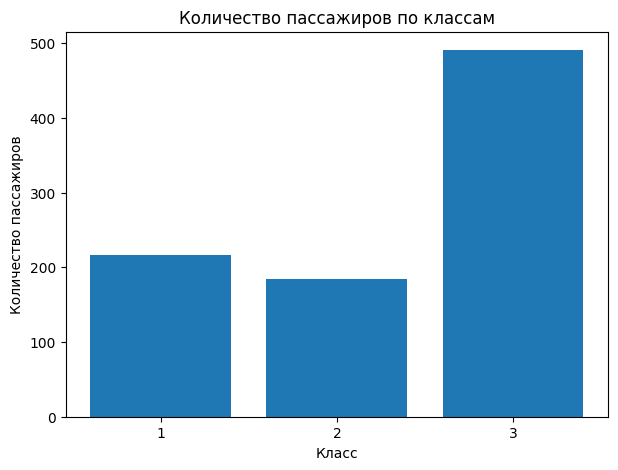

In [24]:
class_counts = df['Pclass'].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.title('Количество пассажиров по классам')
plt.xlabel('Класс')
plt.ylabel('Количество пассажиров')
plt.show()


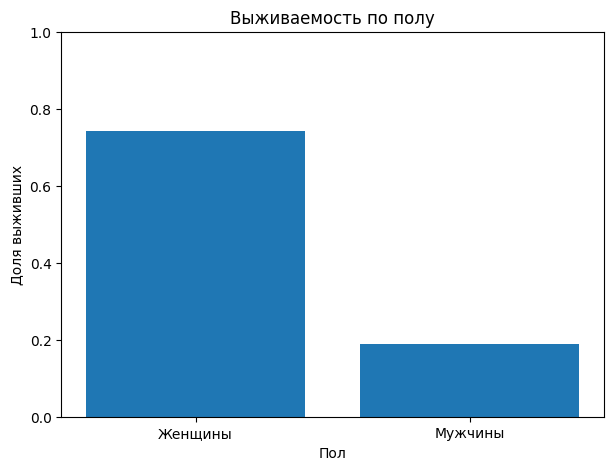

In [25]:
# График выживаемости по полу
survival_sex = df.groupby('Sex')['Survived'].mean()

plt.figure(figsize=(7, 5))
plt.bar(['Женщины', 'Мужчины'],
        [survival_sex.get('female', 0), survival_sex.get('male', 0)])
plt.title('Выживаемость по полу')
plt.xlabel('Пол')
plt.ylabel('Доля выживших')
plt.ylim(0, 1)
plt.show()
